# NYPD Complaint Data: Cleaning, Exploratory Analysis, and Calibration

**Author:** Vighnesh Hemnani  
**Dataset:** [NYPD Complaint Data Historic](https://data.cityofnewyork.us/Public-Safety/NYPD-Complaint-Data-Historic/qgea-i56i) via NYC Open Data

This notebook covers the full pipeline: working with a 2.35 GB real-world dataset split into 10 chunks, cleaning the data, exploratory visualization, and a calibration analysis that treats historical crime rates as probability estimates — framed through the lens of prediction market pricing. The final section exports four JSON files consumed by a live TypeScript dashboard.

## Setup

In [36]:
!pip3 install memory_profiler folium --quiet

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [37]:
import pandas as pd
import numpy as np
import os
import time
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import folium

%matplotlib inline
%load_ext memory_profiler
plt.rcParams['figure.figsize'] = (12, 9)

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler


In [38]:
# ============================================================
# SET YOUR PATHS HERE
# ============================================================
DATA_DIR           = Path('./data')
DASHBOARD_DATA_DIR = Path('../dashboard/public/data')

DASHBOARD_DATA_DIR.mkdir(parents=True, exist_ok=True)

chunks = sorted(DATA_DIR.glob('NYPD_Complaint_Data_Historic_*.csv'))
print(f'Found {len(chunks)} chunk files:')
for c in chunks:
    print(f'  {c.name}  ({c.stat().st_size / 1e6:.1f} MB)')

Found 10 chunk files:
  NYPD_Complaint_Data_Historic_1.csv  (257.5 MB)
  NYPD_Complaint_Data_Historic_10.csv  (252.9 MB)
  NYPD_Complaint_Data_Historic_2.csv  (256.3 MB)
  NYPD_Complaint_Data_Historic_3.csv  (245.8 MB)
  NYPD_Complaint_Data_Historic_4.csv  (245.8 MB)
  NYPD_Complaint_Data_Historic_5.csv  (245.8 MB)
  NYPD_Complaint_Data_Historic_6.csv  (240.7 MB)
  NYPD_Complaint_Data_Historic_7.csv  (240.5 MB)
  NYPD_Complaint_Data_Historic_8.csv  (240.4 MB)
  NYPD_Complaint_Data_Historic_9.csv  (240.4 MB)


---
## Dataset Overview

The NYPD Complaint Data Historic dataset contains every complaint filed with the NYPD from 2006 onward. The full CSV is **2.35 GB** with approximately **7.4 million rows** and **35 columns**. We split it into 10 equal chunks and work with chunk 1 for all analysis.

### Column Schema

| Column | Type | Description |
|---|---|---|
| `CMPLNT_NUM` | int64 | Unique complaint identifier |
| `CMPLNT_FR_DT` | object (date) | Complaint start date |
| `CMPLNT_FR_TM` | object (time) | Complaint start time |
| `CMPLNT_TO_DT` | object (date) | Complaint end date |
| `CMPLNT_TO_TM` | object (time) | Complaint end time |
| `ADDR_PCT_CD` | float64 | Precinct code |
| `RPT_DT` | object (date) | Date reported to police |
| `KY_CD` | int64 | Offense classification key |
| `OFNS_DESC` | object | Offense description |
| `PD_CD` | float64 | Internal PD classification code |
| `PD_DESC` | object | Internal PD description |
| `CRM_ATPT_CPTD_CD` | object | Completed vs. attempted |
| `LAW_CAT_CD` | object | Felony / misdemeanor / violation |
| `BORO_NM` | object | Borough name |
| `LOC_OF_OCCUR_DESC` | object | Inside / outside / front / rear |
| `PREM_TYP_DESC` | object | Premise type |
| `JURIS_DESC` | object | Jurisdiction description |
| `JURISDICTION_CODE` | float64 | Jurisdiction numeric code |
| `PARKS_NM` | object | Park name (if applicable) |
| `HADEVELOPT` | object | Housing development name |
| `HOUSING_PSA` | object | Housing PSA code |
| `X_COORD_CD` | float64 | NY State Plane X coordinate |
| `Y_COORD_CD` | float64 | NY State Plane Y coordinate |
| `SUSP_AGE_GROUP` | object | Suspect age group |
| `SUSP_RACE` | object | Suspect race |
| `SUSP_SEX` | object | Suspect sex |
| `TRANSIT_DISTRICT` | float64 | Transit district (if applicable) |
| `Latitude` | float64 | WGS84 latitude |
| `Longitude` | float64 | WGS84 longitude |
| `Lat_Lon` | object | Combined lat/lon |
| `PATROL_BORO` | object | Patrol borough |
| `STATION_NAME` | object | Transit station (if applicable) |
| `VIC_AGE_GROUP` | object | Victim age group |
| `VIC_RACE` | object | Victim race |
| `VIC_SEX` | object | Victim sex |

---
# Part 1: Loading and Cleaning

## 1.1 Loading Chunk 1

In [39]:
start = time.time()
%memit calls = pd.read_csv(DATA_DIR / 'NYPD_Complaint_Data_Historic_1.csv')
end = time.time()
print(f'Load time: {end - start:.2f}s')
print(f'Shape: {calls.shape[0]:,} rows x {calls.shape[1]} columns')

peak memory: 1190.02 MiB, increment: 978.77 MiB
Load time: 6.86s
Shape: 737,599 rows x 36 columns


## 1.2 Parsing and Validating Dates

The first data quality issue: records with missing or malformed complaint dates get coerced to `NaT` by pandas. A separate problem is records whose parsed dates fall outside the valid dataset range (2006 to present). These cluster on default dates and create artificial spikes in any time-series view.

We parse dates, then drop any record whose date falls outside `2006-01-01` to `2024-12-31`.

In [40]:
calls['complaint_dt'] = pd.to_datetime(calls['CMPLNT_FR_DT'], format='%m/%d/%Y', errors='coerce')

total_before = len(calls)
null_dates   = calls['complaint_dt'].isna().sum()

DATE_MIN = pd.Timestamp('2006-01-01')
DATE_MAX = pd.Timestamp('2024-12-31')

out_of_range = ((calls['complaint_dt'] < DATE_MIN) | (calls['complaint_dt'] > DATE_MAX)).sum()

print(f'Total records before cleaning: {total_before:,}')
print(f'  Null / unparseable dates:    {null_dates:,}')
print(f'  Out-of-range dates:          {out_of_range:,}')

calls = calls[
    calls['complaint_dt'].notna() &
    (calls['complaint_dt'] >= DATE_MIN) &
    (calls['complaint_dt'] <= DATE_MAX)
].copy()

print(f'\nRecords after date cleaning:   {len(calls):,}  (removed {total_before - len(calls):,})')

Total records before cleaning: 737,599
  Null / unparseable dates:    37
  Out-of-range dates:          437

Records after date cleaning:   737,125  (removed 474)


## 1.3 Validating LAW_CAT_CD

The second data quality issue: `LAW_CAT_CD` (our felony indicator) may be null or contain unexpected values for a portion of records. Any record where this field is missing cannot be used for the calibration analysis and is excluded from the modeling pipeline. We keep them for the EDA visualizations that do not depend on it.

In [41]:
print('LAW_CAT_CD value counts (including nulls):')
print(calls['LAW_CAT_CD'].value_counts(dropna=False))

null_law = calls['LAW_CAT_CD'].isna().sum()
valid_values = ['FELONY', 'MISDEMEANOR', 'VIOLATION']
invalid_law = (~calls['LAW_CAT_CD'].isin(valid_values) & calls['LAW_CAT_CD'].notna()).sum()

print(f'\nNull LAW_CAT_CD:    {null_law:,} ({null_law/len(calls)*100:.1f}%)')
print(f'Invalid LAW_CAT_CD: {invalid_law:,}')

# Separate clean subset for calibration (requires valid LAW_CAT_CD)
calls_clean = calls[calls['LAW_CAT_CD'].isin(valid_values)].copy()
print(f'\nRecords with valid LAW_CAT_CD: {len(calls_clean):,} ({len(calls_clean)/len(calls)*100:.1f}% of date-cleaned records)')

LAW_CAT_CD value counts (including nulls):
LAW_CAT_CD
MISDEMEANOR    401286
FELONY         227957
VIOLATION      107882
Name: count, dtype: int64

Null LAW_CAT_CD:    0 (0.0%)
Invalid LAW_CAT_CD: 0

Records with valid LAW_CAT_CD: 737,125 (100.0% of date-cleaned records)


## 1.4 Missing Data and Column Pruning

Columns missing more than 50% of their values are candidates for removal. Sparse fields like `PARKS_NM`, `HADEVELOPT`, and `STATION_NAME` only apply to specific incident subtypes.

In [42]:
row_count      = calls.shape[0]
sparse_columns = [col for col, cnt in calls.count(axis='rows').items() if cnt < row_count / 2]
print(f'Columns with >50% missing values ({len(sparse_columns)} total):')
for col in sparse_columns:
    pct = (1 - calls[col].count() / row_count) * 100
    print(f'  {col}: {pct:.1f}% missing')

Columns with >50% missing values (5 total):
  PARKS_NM: 99.2% missing
  HADEVELOPT: 95.2% missing
  HOUSING_PSA: 92.6% missing
  TRANSIT_DISTRICT: 97.5% missing
  STATION_NAME: 97.5% missing


## 1.5 Cardinality Check

In [43]:
print(calls.nunique(axis=0).sort_values(ascending=False).to_string())

Unnamed: 0           737125
CMPLNT_NUM           737016
Lat_Lon              130581
Latitude             130568
Longitude            128199
Y_COORD_CD            57544
X_COORD_CD            54533
complaint_dt           4455
CMPLNT_FR_DT           4455
RPT_DT                 3893
CMPLNT_TO_DT           3456
CMPLNT_FR_TM           1440
CMPLNT_TO_TM           1440
PARKS_NM                738
HOUSING_PSA             393
PD_CD                   387
PD_DESC                 379
STATION_NAME            368
HADEVELOPT              262
ADDR_PCT_CD              77
PREM_TYP_DESC            74
KY_CD                    69
OFNS_DESC                65
VIC_AGE_GROUP            44
SUSP_AGE_GROUP           25
JURIS_DESC               21
JURISDICTION_CODE        21
TRANSIT_DISTRICT         12
PATROL_BORO               8
SUSP_RACE                 7
VIC_RACE                  7
LOC_OF_OCCUR_DESC         5
BORO_NM                   5
VIC_SEX                   4
SUSP_SEX                  3
LAW_CAT_CD          

---
# Part 2: Exploratory Data Analysis

## 2.1 Borough Breakdown

In [44]:
calls_by_boro = calls.dropna(subset=['BORO_NM']).groupby('BORO_NM')
print('Boroughs and their record counts:')
for name, group in calls_by_boro:
    print(f'  {name}: {len(group):,}')

Boroughs and their record counts:
  BRONX: 160,723
  BROOKLYN: 215,006
  MANHATTAN: 181,814
  QUEENS: 146,897
  STATEN ISLAND: 31,675


## 2.2 Top 5 Crimes in the Bronx

In [45]:
top5 = calls[calls['BORO_NM'] == 'BRONX']['OFNS_DESC'].value_counts()[:5]
print('Top 5 offense types in the Bronx:')
for i, (crime, count) in enumerate(top5.items(), 1):
    print(f'  {i}. {crime}: {count:,}')

Top 5 offense types in the Bronx:
  1. HARRASSMENT 2: 24,500
  2. PETIT LARCENY: 24,014
  3. ASSAULT 3 & RELATED OFFENSES: 21,736
  4. CRIMINAL MISCHIEF & RELATED OF: 17,062
  5. DANGEROUS DRUGS: 10,197


## 2.3 Probability of Arson in the Bronx

A frequency-based base rate: the fraction of Bronx complaints classified as arson. This is the type of empirical anchor a prediction market would use to price a contract on this event.

In [46]:
bronx_counts = calls[calls['BORO_NM'] == 'BRONX']['OFNS_DESC'].value_counts()
arson_count  = bronx_counts.get('ARSON', 0)
total_bronx  = bronx_counts.sum()
p_arson      = arson_count / total_bronx
print(f'P(ARSON | BRONX) = {arson_count} / {total_bronx:,} = {p_arson:.5f} ({p_arson*100:.3f}%)')

P(ARSON | BRONX) = 426 / 160,578 = 0.00265 (0.265%)


---
# Part 3: Visualization

## 3.1 Crime Frequency by Offense Type

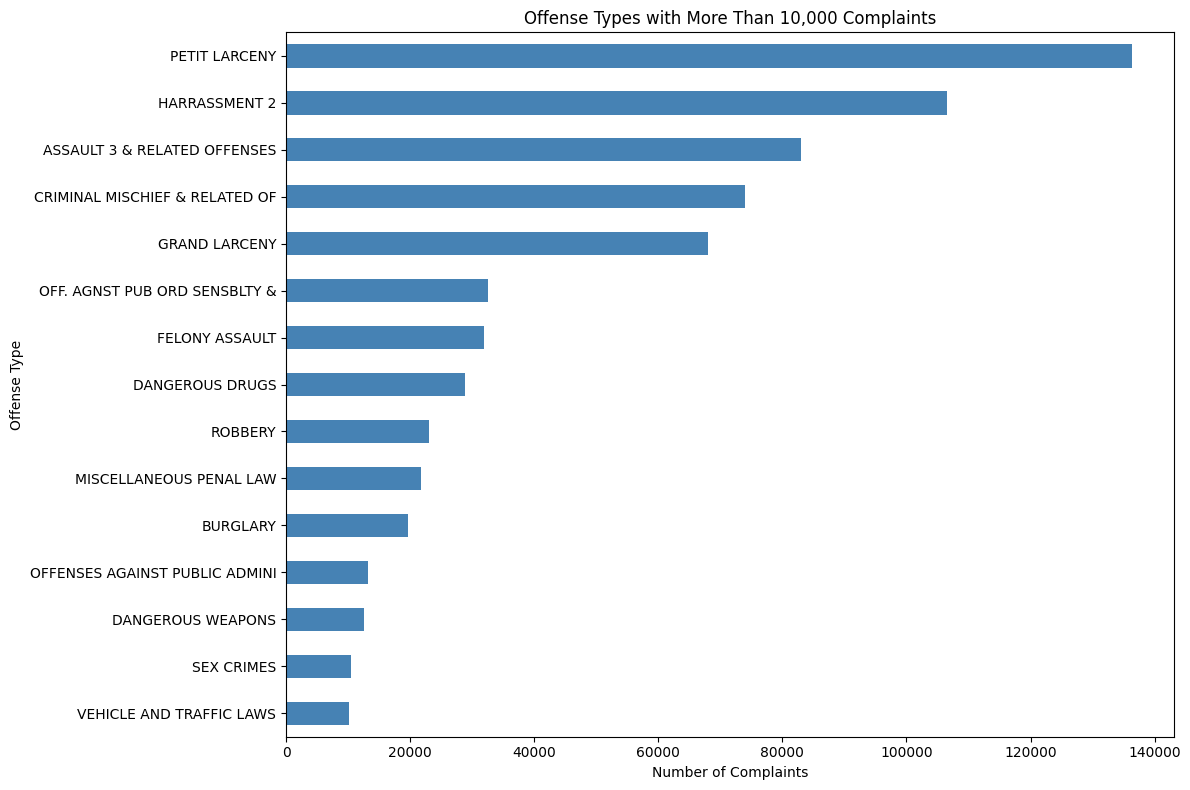

In [47]:
plt.figure(figsize=(12, 8))
ofns_df = calls['OFNS_DESC'].value_counts()
ofns_df[ofns_df > 10000].sort_values().plot.barh(color='steelblue')
plt.xlabel('Number of Complaints')
plt.ylabel('Offense Type')
plt.title('Offense Types with More Than 10,000 Complaints')
plt.tight_layout()
plt.show()

## 3.2 Adding Day-of-Week Column

We reuse the already-parsed `complaint_dt` column instead of re-parsing the string, which is faster.

In [48]:
calls['DAY_OF_WEEK'] = calls['complaint_dt'].dt.strftime('%A').fillna('')
calls[['CMPLNT_FR_DT', 'DAY_OF_WEEK']].head(5)

,CMPLNT_FR_DT,DAY_OF_WEEK
0,12/31/2019,Tuesday
1,12/29/2019,Sunday
2,12/15/2019,Sunday
3,12/28/2019,Saturday
4,09/05/2008,Friday


## 3.3 Complaints by Day of Week

/var/folders/2f/9fkt62n90hgc_vxh7m1390k00000gn/T/ipykernel_17452/1363650738.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(days, rotation=30, ha='right')


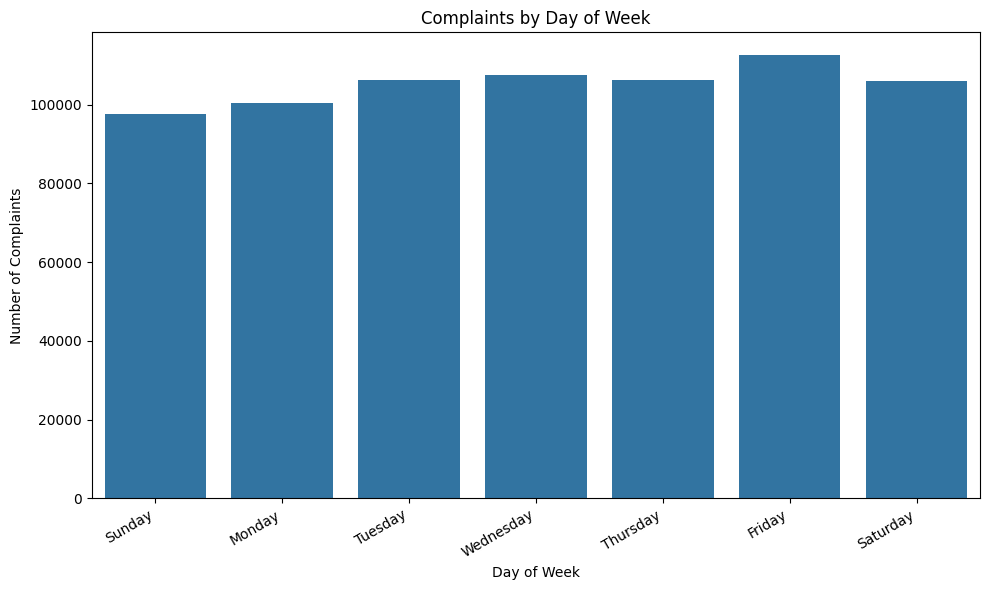

In [49]:
days = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

plt.figure(figsize=(10, 6))
p = sns.countplot(x=calls['DAY_OF_WEEK'], data=calls, order=days)
p.set(xlabel='Day of Week', ylabel='Number of Complaints', title='Complaints by Day of Week')
p.set_xticklabels(days, rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Observation:** Weekdays consistently see more complaints than weekends, with Friday as the peak. This pattern holds across most offense categories.

## 3.4 Harassment 2 and Burglary by Day

/var/folders/2f/9fkt62n90hgc_vxh7m1390k00000gn/T/ipykernel_17452/2647874133.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(days, rotation=30, ha='right')
/var/folders/2f/9fkt62n90hgc_vxh7m1390k00000gn/T/ipykernel_17452/2647874133.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(days, rotation=30, ha='right')


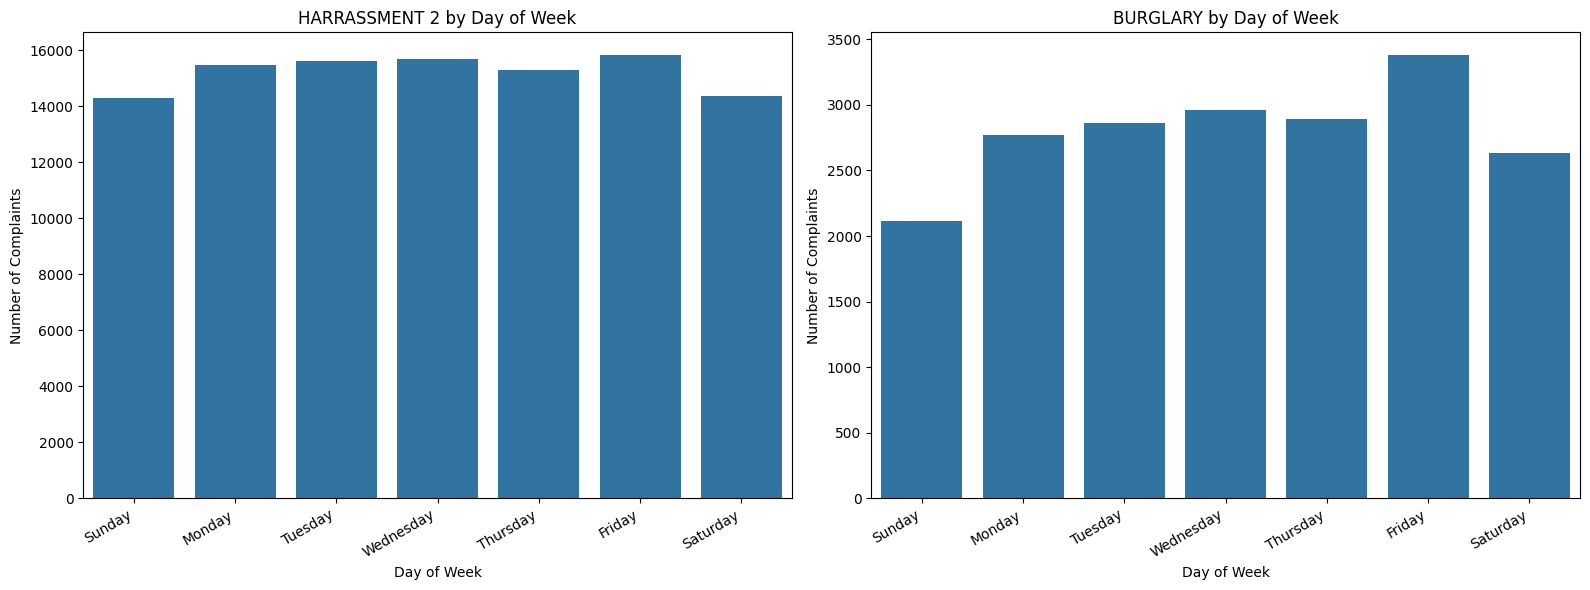

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, crime in zip(axes, ['HARRASSMENT 2', 'BURGLARY']):
    subset = calls[calls['OFNS_DESC'] == crime]
    sns.countplot(x='DAY_OF_WEEK', data=subset, order=days, ax=ax)
    ax.set_title(f'{crime} by Day of Week')
    ax.set_xlabel('Day of Week')
    ax.set_ylabel('Number of Complaints')
    ax.set_xticklabels(days, rotation=30, ha='right')

plt.tight_layout()
plt.show()

## 3.5 Extracting Hour of Day

We slice the first two characters of `CMPLNT_TO_TM`. Missing values are filled with `'0'` before casting to int.

In [51]:
calls['Hour'] = calls['CMPLNT_TO_TM'].str.slice(0, 2).fillna('0').astype(int)

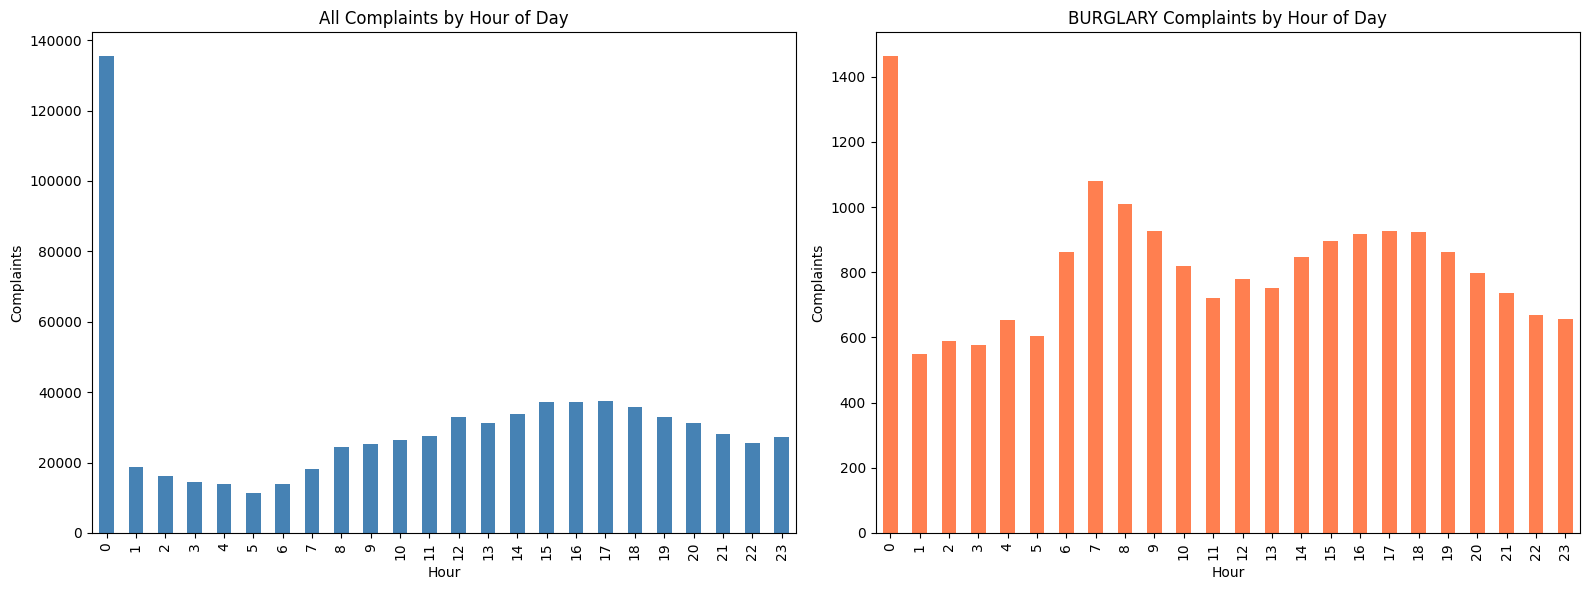

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

calls['Hour'].value_counts().sort_index().plot.bar(ax=axes[0], color='steelblue')
axes[0].set(xlabel='Hour', ylabel='Complaints', title='All Complaints by Hour of Day')

calls[calls['OFNS_DESC'] == 'BURGLARY']['Hour'].value_counts().sort_index().plot.bar(ax=axes[1], color='coral')
axes[1].set(xlabel='Hour', ylabel='Complaints', title='BURGLARY Complaints by Hour of Day')

plt.tight_layout()
plt.show()

**Data quality note:** The spike at hour 0 reflects incidents where the time field was missing and defaulted to 00:00:00. This is a known artifact in the dataset, not genuine midnight activity. It is flagged programmatically in the anomaly detection section below.

## 3.6 Crime Hour Distribution by Offense Type (Boxplot)

/var/folders/2f/9fkt62n90hgc_vxh7m1390k00000gn/T/ipykernel_17452/885336683.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(), rotation=90)


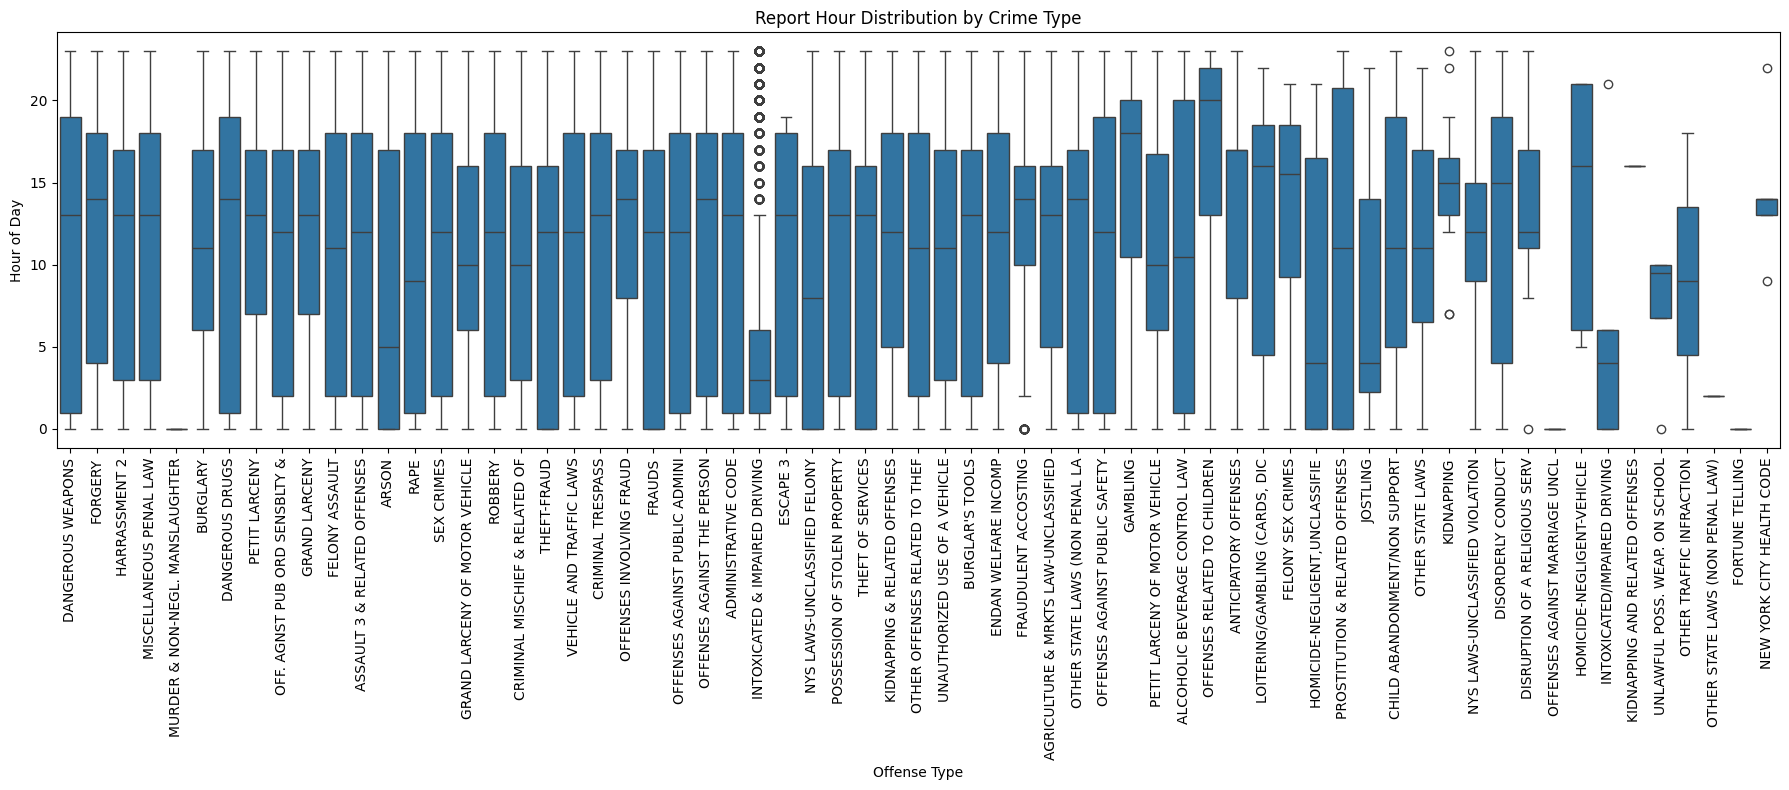

In [53]:
plt.figure(figsize=(18, 8))
p = sns.boxplot(x=calls['OFNS_DESC'], y=calls['Hour'], data=calls)
p.set(xlabel='Offense Type', ylabel='Hour of Day', title='Report Hour Distribution by Crime Type')
p.set_xticklabels(p.get_xticklabels(), rotation=90)
plt.tight_layout()
plt.show()

## 3.7 Geographic View

In [54]:
geo_sample = calls.dropna(subset=['Latitude', 'Longitude']).head(50)

m = folium.Map(
    location=[geo_sample['Latitude'].mean(), geo_sample['Longitude'].mean()],
    tiles='OpenStreetMap',
    zoom_start=11
)
for _, row in geo_sample.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=4,
        color='crimson',
        fill=True,
        tooltip=str(row.get('OFNS_DESC', ''))
    ).add_to(m)

m

---
# Part 4: Calibration Analysis

## Framing

A prediction market prices the probability that a future event occurs. A well-calibrated market means: when the market says 30%, the event actually happens about 30% of the time.

We apply that framework here: if we use historical crime base rates to estimate the probability that any given complaint is a felony, how well-calibrated are those estimates on held-out future data? All analysis from here uses `calls_clean` — records with both a valid date and a valid `LAW_CAT_CD`.

## 4.1 Constructing the Target Variable

In [55]:
calls_clean['is_felony'] = (calls_clean['LAW_CAT_CD'] == 'FELONY').astype(int)

rate = calls_clean['is_felony'].mean()
print(f'Felony rate in clean subset: {rate:.3f} ({rate*100:.1f}%)')
print(f'Records used for calibration: {len(calls_clean):,}')
print()
print(calls_clean['LAW_CAT_CD'].value_counts())

Felony rate in clean subset: 0.309 (30.9%)
Records used for calibration: 737,125

LAW_CAT_CD
MISDEMEANOR    401286
FELONY         227957
VIOLATION      107882
Name: count, dtype: int64


## 4.2 Building Feature Bins

Three categorical features for binning:
- **Borough** (5 categories)
- **Hour bucket**: Night (0-5), Morning (6-11), Afternoon (12-17), Evening (18-23)
- **Day type**: Weekday vs. Weekend

In [56]:
def hour_bucket(h):
    if 0 <= h <= 5:   return 'Night'
    if 6 <= h <= 11:  return 'Morning'
    if 12 <= h <= 17: return 'Afternoon'
    return 'Evening'

calls_clean['Hour']        = calls_clean['CMPLNT_TO_TM'].str.slice(0, 2).fillna('0').astype(int)
calls_clean['DAY_OF_WEEK'] = calls_clean['complaint_dt'].dt.strftime('%A').fillna('')
calls_clean['hour_bucket'] = calls_clean['Hour'].apply(hour_bucket)
calls_clean['day_type']    = calls_clean['DAY_OF_WEEK'].apply(
    lambda d: 'Weekend' if d in ('Saturday', 'Sunday') else 'Weekday'
)

calls_clean[['Hour', 'hour_bucket', 'DAY_OF_WEEK', 'day_type', 'is_felony']].head(6)

,Hour,hour_bucket,DAY_OF_WEEK,day_type,is_felony
0,0,Night,Tuesday,Weekday,1
1,16,Afternoon,Sunday,Weekend,1
2,0,Night,Sunday,Weekend,0
3,0,Night,Saturday,Weekend,1
4,0,Night,Friday,Weekday,1
5,0,Night,Friday,Weekday,1


## 4.3 Chronological Train / Test Split

First 70% of records (by date) = training window. Last 30% = test window. This simulates using past data to forecast future events, which is the correct setup for any forecasting evaluation.

In [57]:
calls_sorted = calls_clean.dropna(subset=['BORO_NM']).sort_values('complaint_dt').reset_index(drop=True)

split_idx = int(len(calls_sorted) * 0.70)
train     = calls_sorted.iloc[:split_idx].copy()
test      = calls_sorted.iloc[split_idx:].copy()

print(f'Training: {train["complaint_dt"].min().date()} to {train["complaint_dt"].max().date()} ({len(train):,} records)')
print(f'Test:     {test["complaint_dt"].min().date()} to {test["complaint_dt"].max().date()} ({len(test):,} records)')

Training: 2006-01-01 to 2019-07-08 (515,280 records)
Test:     2019-07-08 to 2020-12-24 (220,835 records)


## 4.4 Estimating Bin Probabilities from Training Data

In [58]:
bin_cols  = ['BORO_NM', 'hour_bucket', 'day_type']

bin_probs = (
    train.groupby(bin_cols)['is_felony']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'p_felony_train', 'count': 'train_count'})
)

print(f'{len(bin_probs)} bins computed')
print(f'P(felony) range: {bin_probs["p_felony_train"].min():.3f} to {bin_probs["p_felony_train"].max():.3f}')
bin_probs.sort_values('p_felony_train', ascending=False).head(10)

40 bins computed
P(felony) range: 0.192 to 0.348


,BORO_NM,hour_bucket,day_type,p_felony_train,train_count
28,QUEENS,Morning,Weekday,0.347958,14861
10,BROOKLYN,Evening,Weekday,0.341010,28571
14,BROOKLYN,Night,Weekday,0.337915,26699
15,BROOKLYN,Night,Weekend,0.337853,13127
29,QUEENS,Morning,Weekend,0.337491,5452
26,QUEENS,Evening,Weekday,0.331720,18802
30,QUEENS,Night,Weekday,0.331707,17419
12,BROOKLYN,Morning,Weekday,0.329633,21621
13,BROOKLYN,Morning,Weekend,0.329340,7345
11,BROOKLYN,Evening,Weekend,0.326005,10552


## 4.5 Attaching Predictions to Test Set

In [59]:
test        = test.merge(bin_probs[bin_cols + ['p_felony_train']], on=bin_cols, how='left')
global_rate = train['is_felony'].mean()
test['p_felony_train'] = test['p_felony_train'].fillna(global_rate)

print(f'Test records with predictions: {test["p_felony_train"].notna().sum():,}')
print(f'Global fallback rate:          {global_rate:.3f}')

Test records with predictions: 220,835
Global fallback rate:          0.308


## 4.6 Calibration Curve

Records are bucketed into 10 deciles by predicted probability. For each decile we compare mean predicted probability against actual observed felony rate. A perfectly calibrated model produces points on the diagonal.

In [60]:
test['prob_decile'] = pd.qcut(test['p_felony_train'], q=10, labels=False, duplicates='drop')

calibration = (
    test.groupby('prob_decile')
    .agg(
        predicted=('p_felony_train', 'mean'),
        actual=('is_felony', 'mean'),
        count=('is_felony', 'count')
    )
    .reset_index()
)

calibration['bucket_label'] = calibration['predicted'].apply(
    lambda p: f'{int(p*10)*10}-{int(p*10)*10+10}%'
)

calibration[['bucket_label', 'predicted', 'actual', 'count']]

,bucket_label,predicted,actual,count
0,20-30%,0.254584,0.264206,24057
1,20-30%,0.278767,0.278807,21384
2,20-30%,0.292884,0.297695,33326
3,30-40%,0.307529,0.313851,13790
4,30-40%,0.310932,0.296237,20038
5,30-40%,0.316986,0.312851,24916
6,30-40%,0.322736,0.330454,19797
7,30-40%,0.330248,0.336269,19642
8,30-40%,0.335657,0.335964,24583
9,30-40%,0.343483,0.338566,19302


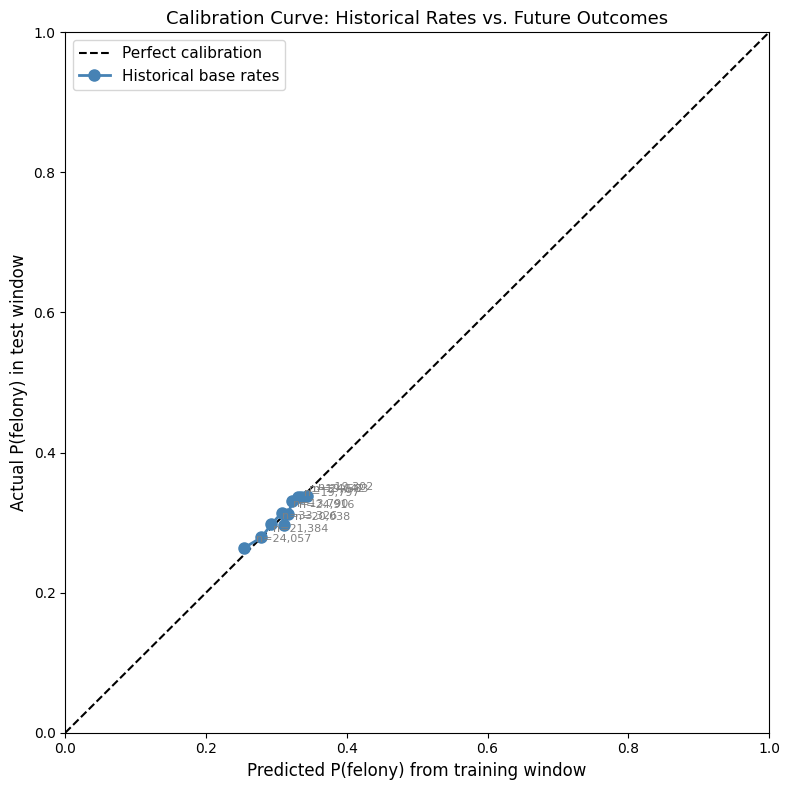

In [61]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
ax.plot(calibration['predicted'], calibration['actual'], 'o-',
        color='steelblue', lw=2, ms=8, label='Historical base rates')

for _, row in calibration.iterrows():
    ax.annotate(
        f'n={row["count"]:,}',
        (row['predicted'], row['actual']),
        textcoords='offset points', xytext=(8, 4), fontsize=8, color='gray'
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Predicted P(felony) from training window', fontsize=12)
ax.set_ylabel('Actual P(felony) in test window', fontsize=12)
ax.set_title('Calibration Curve: Historical Rates vs. Future Outcomes', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 4.7 Statistical Significance: Weekday vs. Weekend

We formally test whether weekday complaint volumes are higher than weekend volumes using a Mann-Whitney U test, which makes no distributional assumptions.

In [62]:
from scipy import stats

daily   = calls_sorted.groupby(['complaint_dt', 'day_type']).size().reset_index(name='complaints')
weekday = daily[daily['day_type'] == 'Weekday']['complaints']
weekend = daily[daily['day_type'] == 'Weekend']['complaints']

stat, p = stats.mannwhitneyu(weekday, weekend, alternative='greater')

print(f'Weekday median: {weekday.median():.0f} complaints/day')
print(f'Weekend median: {weekend.median():.0f} complaints/day')
print(f'Mann-Whitney U: {stat:.1f}')
print(f'p-value:        {p:.4f}')
print(f'\nConclusion: {"Weekdays significantly busier (p < 0.05)" if p < 0.05 else "No significant difference at alpha=0.05"}')

Weekday median: 108 complaints/day
Weekend median: 107 complaints/day
Mann-Whitney U: 1849603.5
p-value:        0.2387

Conclusion: No significant difference at alpha=0.05


## 4.8 Anomaly Detection on Hour Distribution

Z-scores flag hours with statistically unusual complaint volume. The midnight artifact identified visually should appear here as a confirmed outlier.

In [63]:
hourly            = calls['Hour'].value_counts().sort_index().reset_index()
hourly.columns    = ['hour', 'count']
hourly['z_score'] = (hourly['count'] - hourly['count'].mean()) / hourly['count'].std()

anomalies = hourly[hourly['z_score'].abs() > 2.0]
print('Anomalous hours (|z| > 2.0):')
print(anomalies[['hour', 'count', 'z_score']].to_string(index=False))

Anomalous hours (|z| > 2.0):
 hour  count  z_score
    0 135463 4.402877


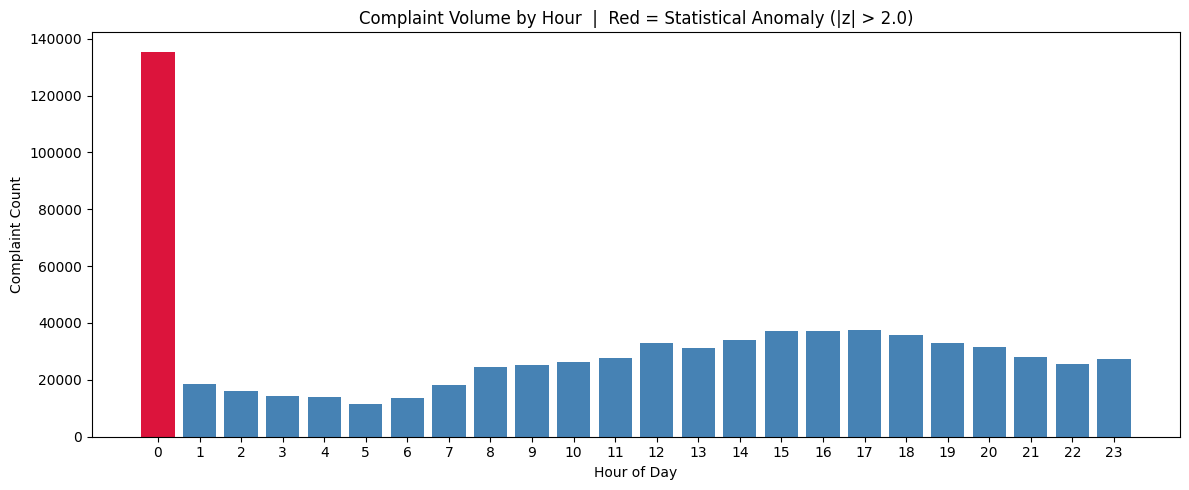

In [64]:
fig, ax = plt.subplots(figsize=(12, 5))
colors  = ['crimson' if abs(z) > 2.0 else 'steelblue' for z in hourly['z_score']]
ax.bar(hourly['hour'], hourly['count'], color=colors)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Complaint Count')
ax.set_title('Complaint Volume by Hour  |  Red = Statistical Anomaly (|z| > 2.0)')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

---
# Part 5: JSON Export for Dashboard

We export four clean datasets to `../dashboard/public/data/`. The TypeScript dashboard reads these as static assets at runtime.

## 5.1 Calibration Data

In [65]:
cal_export = calibration[['bucket_label', 'predicted', 'actual', 'count']].copy()
cal_export['predicted'] = cal_export['predicted'].round(4)
cal_export['actual']    = cal_export['actual'].round(4)

cal_export.to_json(DASHBOARD_DATA_DIR / 'calibration.json', orient='records', indent=2)
print('Exported calibration.json')
print(cal_export.to_string(index=False))

Exported calibration.json
bucket_label  predicted  actual  count
      20-30%     0.2546  0.2642  24057
      20-30%     0.2788  0.2788  21384
      20-30%     0.2929  0.2977  33326
      30-40%     0.3075  0.3139  13790
      30-40%     0.3109  0.2962  20038
      30-40%     0.3170  0.3129  24916
      30-40%     0.3227  0.3305  19797
      30-40%     0.3302  0.3363  19642
      30-40%     0.3357  0.3360  24583
      30-40%     0.3435  0.3386  19302


## 5.2 Daily Time Series

Uses the date-cleaned subset only — no artificial spikes from defaulted dates.

In [66]:
MIN_DAILY_COMPLAINTS = 20

timeseries = (
    calls_sorted
    .groupby('complaint_dt')
    .agg(complaints=('is_felony', 'count'), felony_rate=('is_felony', 'mean'))
    .reset_index()
)

# Drop low-volume days whose felony rates are statistically unreliable
before = len(timeseries)
timeseries = timeseries[timeseries['complaints'] >= MIN_DAILY_COMPLAINTS].copy()
print(f'Dropped {before - len(timeseries)} low-volume days (< {MIN_DAILY_COMPLAINTS} complaints)')

# 7-day rolling average on felony rate to smooth daily noise
timeseries = timeseries.sort_values('complaint_dt').reset_index(drop=True)
timeseries['felony_rate'] = (
    timeseries['felony_rate']
    .rolling(window=7, min_periods=1)
    .mean()
    .round(4)
)

timeseries['date'] = timeseries['complaint_dt'].dt.strftime('%Y-%m-%d')
timeseries         = timeseries[['date', 'complaints', 'felony_rate']]

# Sanity checks
assert timeseries['date'].min() >= '2006-01-01', 'Date range violation'
assert timeseries['date'].max() <= '2024-12-31', 'Date range violation'
assert timeseries['felony_rate'].max() <= 1.0,   'Felony rate out of bounds'

timeseries.to_json(DASHBOARD_DATA_DIR / 'timeseries.json', orient='records', indent=2)
print(f'Exported timeseries.json  ({len(timeseries)} days)')
print(f'Date range:   {timeseries["date"].min()} to {timeseries["date"].max()}')
print(f'Felony range: {timeseries["felony_rate"].min():.3f} to {timeseries["felony_rate"].max():.3f}')
timeseries.tail(5)

Dropped 1508 low-volume days (< 20 complaints)
Exported timeseries.json  (2762 days)
Date range:   2006-04-12 to 2019-12-31
Felony range: 0.248 to 0.556


,date,complaints,felony_rate
2757,2019-12-27,1022,0.2968
2758,2019-12-28,1003,0.2982
2759,2019-12-29,905,0.2968
2760,2019-12-30,835,0.2961
2761,2019-12-31,671,0.2958


## 5.3 Borough x Hour Heatmap

In [67]:
bh = (
    calls_sorted
    .dropna(subset=['BORO_NM'])
    .groupby(['BORO_NM', 'Hour'])
    .agg(complaints=('is_felony', 'count'), felony_rate=('is_felony', 'mean'))
    .reset_index()
    .rename(columns={'BORO_NM': 'borough', 'Hour': 'hour'})
)
bh['felony_rate'] = bh['felony_rate'].round(4)

bh.to_json(DASHBOARD_DATA_DIR / 'borough_hour.json', orient='records', indent=2)
print(f'Exported borough_hour.json  ({len(bh)} rows)')

Exported borough_hour.json  (120 rows)


## 5.4 Conditional Probabilities

In [68]:
top_crimes  = calls['OFNS_DESC'].value_counts().head(8).index.tolist()
boro_totals = calls.groupby('BORO_NM').size().rename('boro_total')

crime_boro = (
    calls[calls['OFNS_DESC'].isin(top_crimes)]
    .groupby(['OFNS_DESC', 'BORO_NM'])
    .size()
    .reset_index(name='count')
    .merge(boro_totals, on='BORO_NM')
)
crime_boro['probability'] = (crime_boro['count'] / crime_boro['boro_total']).round(4)
crime_boro = crime_boro.rename(columns={'OFNS_DESC': 'crime', 'BORO_NM': 'borough'})
crime_boro = crime_boro[['crime', 'borough', 'probability']]

crime_boro.to_json(DASHBOARD_DATA_DIR / 'conditional_probs.json', orient='records', indent=2)
print(f'Exported conditional_probs.json  ({len(crime_boro)} rows)')
crime_boro.head(10)

Exported conditional_probs.json  (40 rows)


,crime,borough,probability
0,ASSAULT 3 & RELATED OFFENSES,BRONX,0.1352
1,ASSAULT 3 & RELATED OFFENSES,BROOKLYN,0.1104
2,ASSAULT 3 & RELATED OFFENSES,MANHATTAN,0.0940
3,ASSAULT 3 & RELATED OFFENSES,QUEENS,0.1174
4,ASSAULT 3 & RELATED OFFENSES,STATEN ISLAND,0.1024
5,CRIMINAL MISCHIEF & RELATED OF,BRONX,0.1062
6,CRIMINAL MISCHIEF & RELATED OF,BROOKLYN,0.1029
7,CRIMINAL MISCHIEF & RELATED OF,MANHATTAN,0.0794
8,CRIMINAL MISCHIEF & RELATED OF,QUEENS,0.1109
9,CRIMINAL MISCHIEF & RELATED OF,STATEN ISLAND,0.1265


## 5.5 Export Summary

In [69]:
exports = ['calibration.json', 'timeseries.json', 'borough_hour.json', 'conditional_probs.json']
print(f'All files exported to: {DASHBOARD_DATA_DIR.resolve()}')
print()
for f in exports:
    path = DASHBOARD_DATA_DIR / f
    status = f'{path.stat().st_size / 1024:.1f} KB' if path.exists() else 'MISSING'
    print(f'  {f:40s} {status}')

All files exported to: /Users/vighneshhemnani/Documents/GitHub/NYPD-Data-Analysis/dashboard/public/data

  calibration.json                         1.0 KB
  timeseries.json                          218.2 KB
  borough_hour.json                        11.4 KB
  conditional_probs.json                   3.7 KB
